Importing matplotlib failed. Plotting will not work.



Diabetes Forecasting (per 1000 people):


20:47:36 - cmdstanpy - INFO - Chain [1] start processing
20:47:52 - cmdstanpy - INFO - Chain [1] done processing


AttributeError: module 'ml_dtypes' has no attribute 'float8_e3m4'
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step  


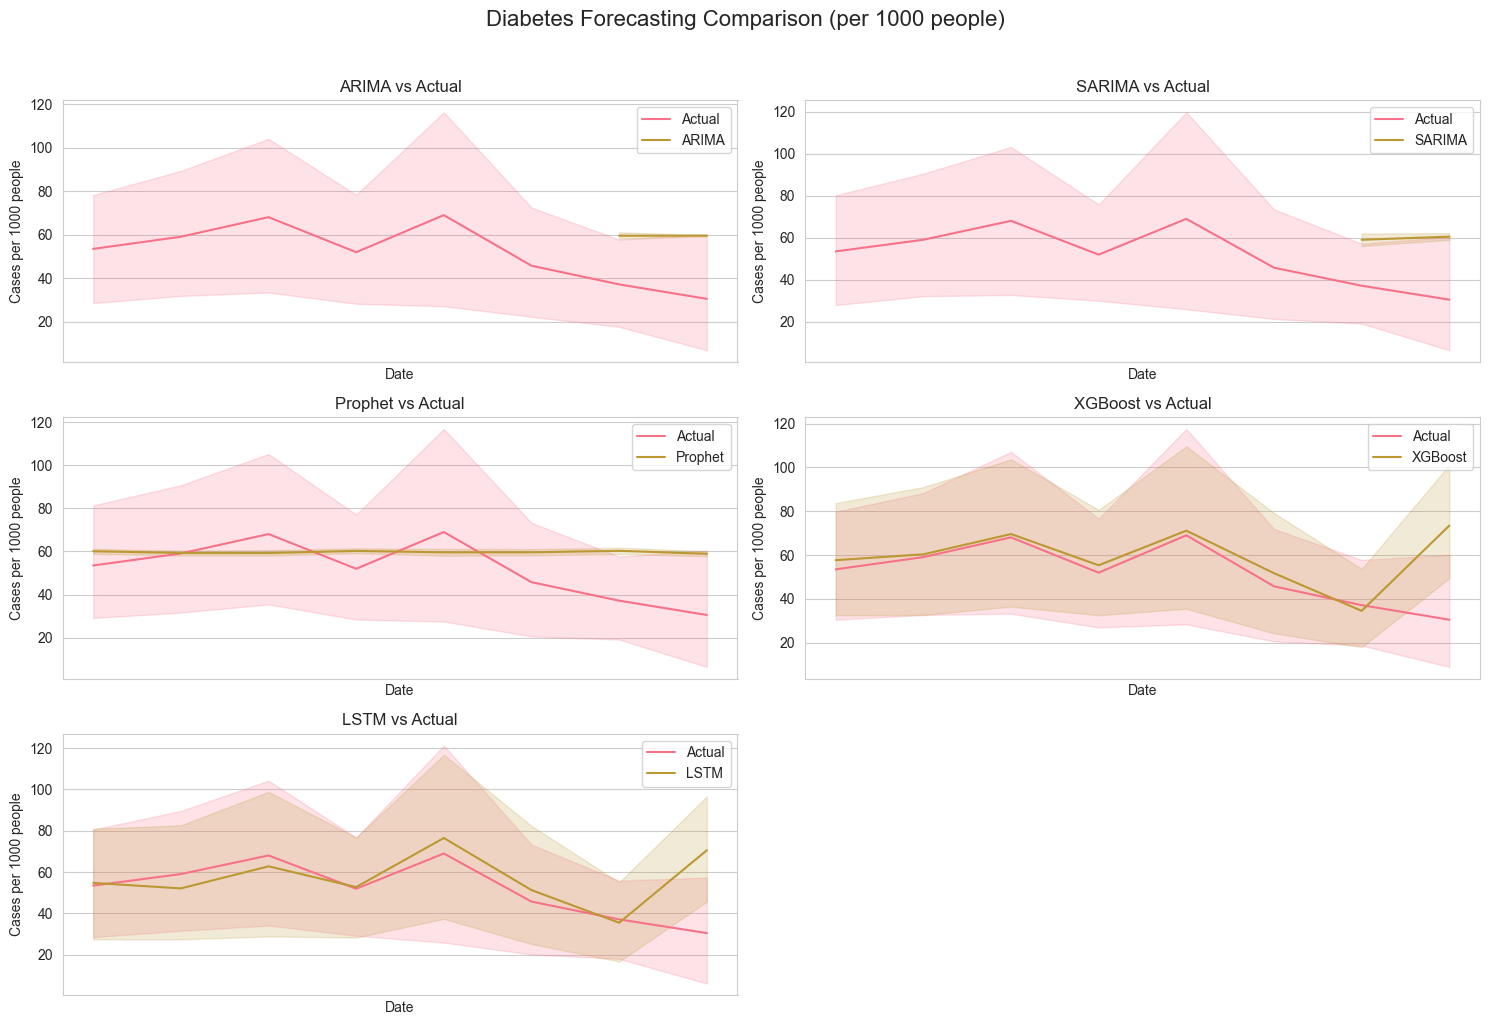

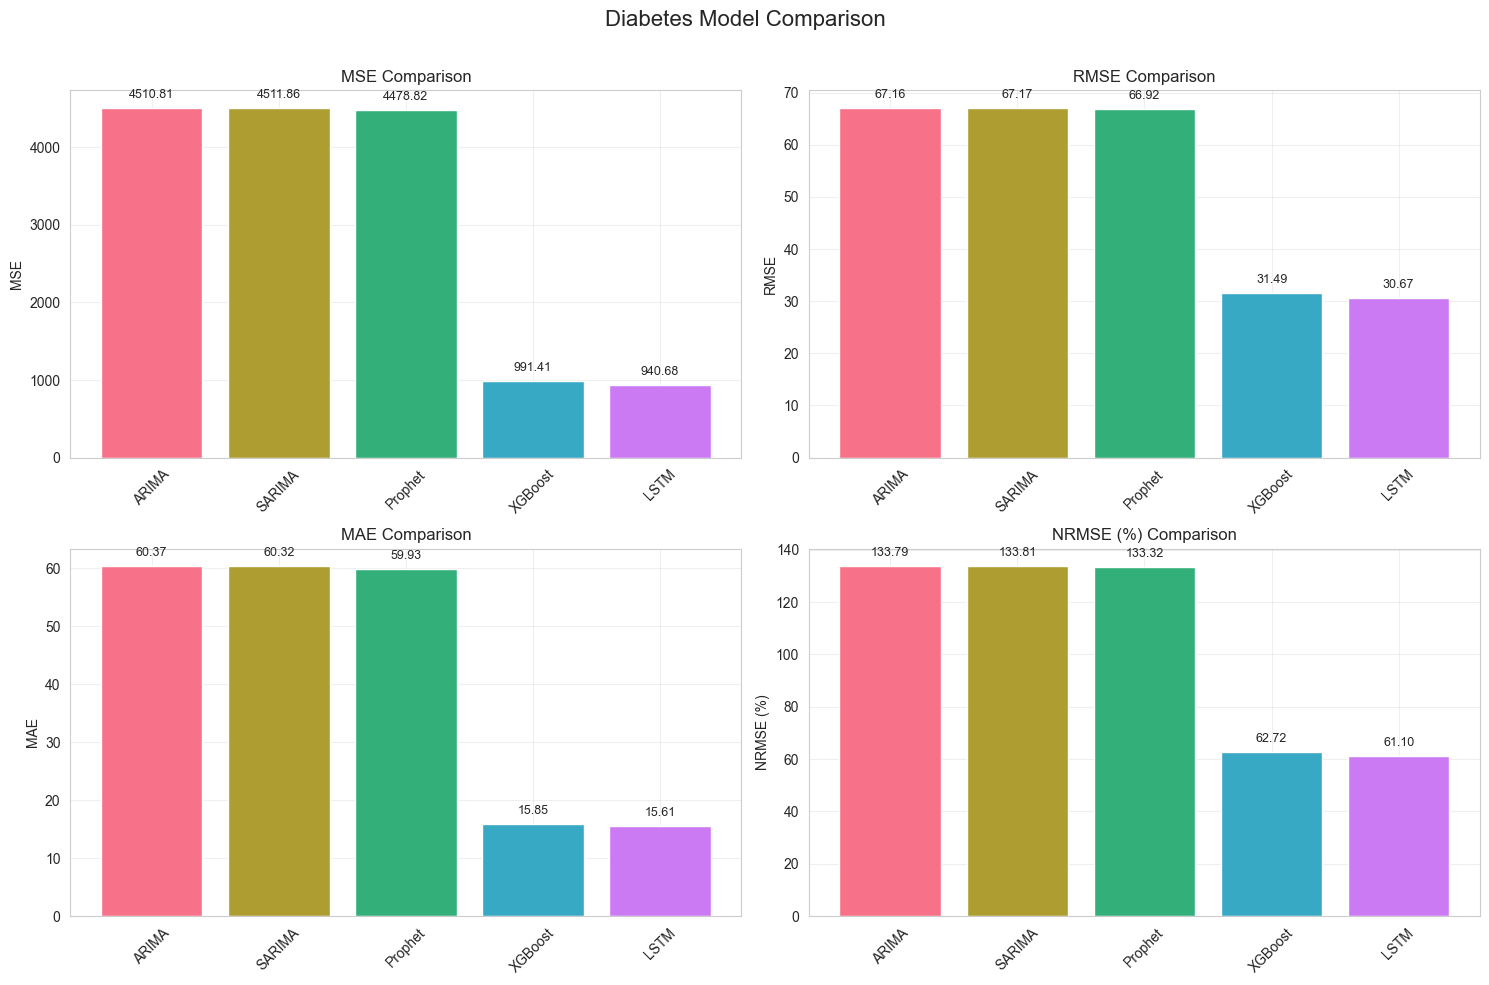

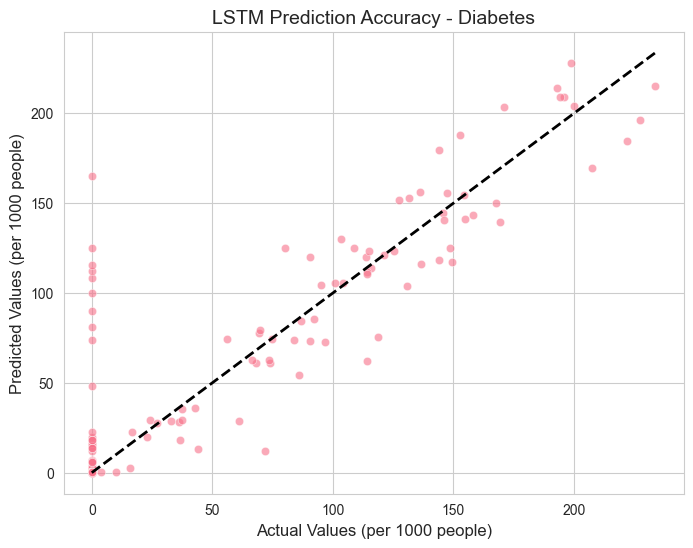


=== Diabetes Model Metrics (per 1000 people) ===
                 MSE       RMSE        MAE   NRMSE (%)
ARIMA    4510.810751  67.162570  60.373599  133.790468
SARIMA   4511.862075  67.170396  60.323817  133.806059
Prophet  4478.817866  66.923971  59.926529  133.315170
XGBoost   991.405624  31.486594  15.853790   62.722529
LSTM      940.683823  30.670569  15.607391   61.096975

High Blood Pressure Forecasting (per 1000 people):


20:48:40 - cmdstanpy - INFO - Chain [1] start processing
20:48:40 - cmdstanpy - INFO - Chain [1] done processing


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 


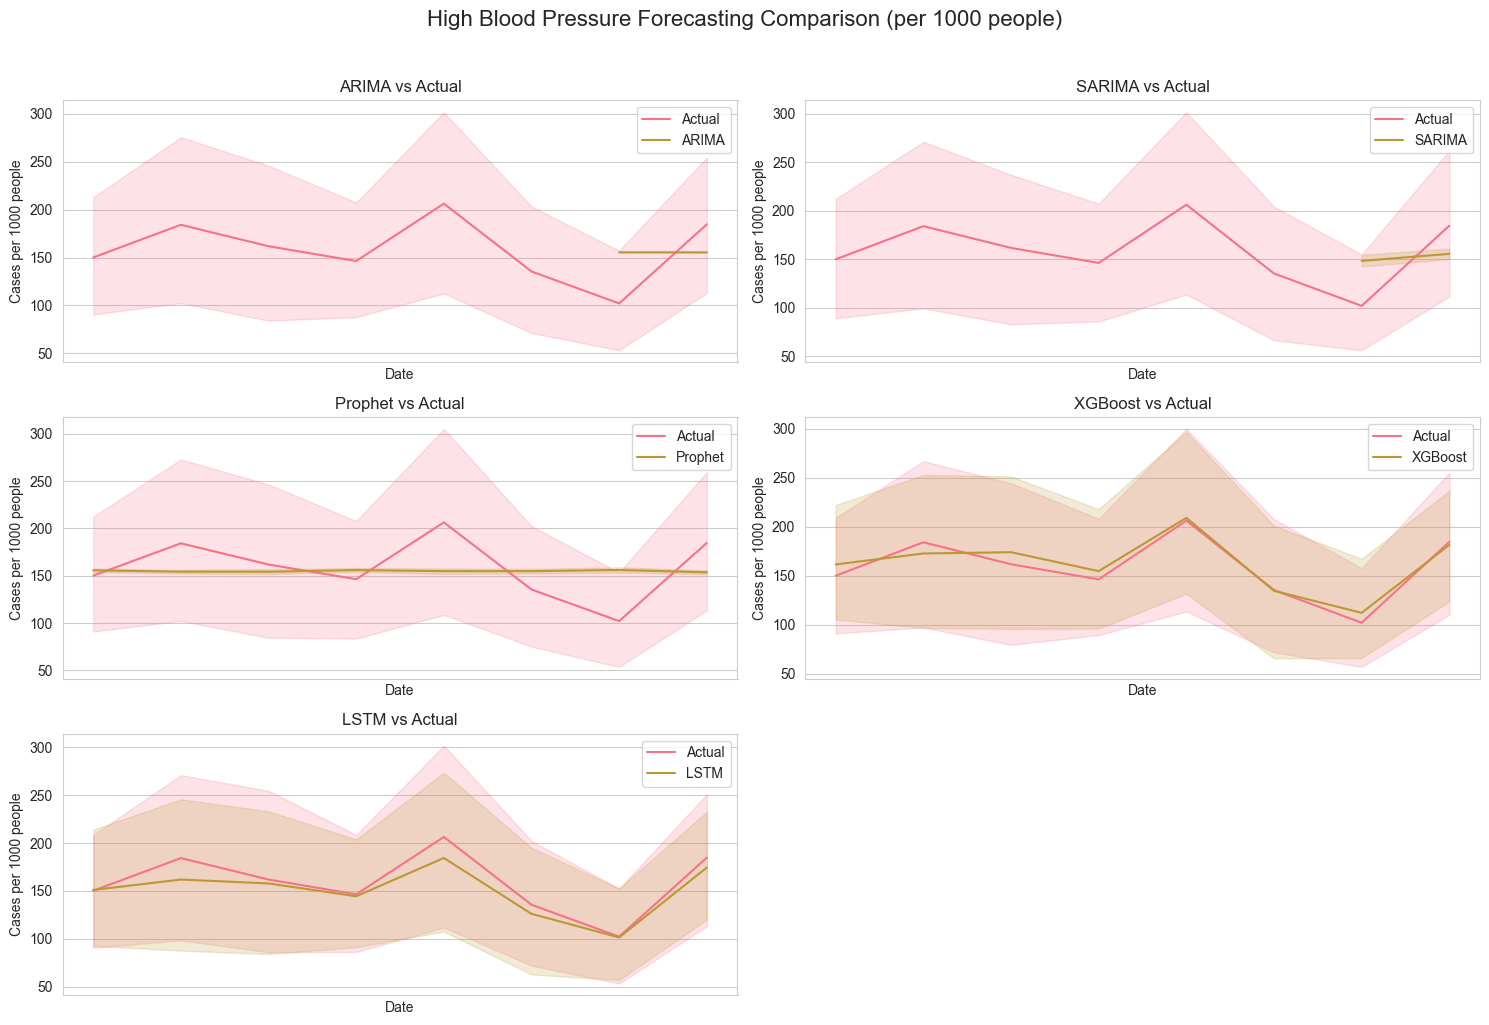

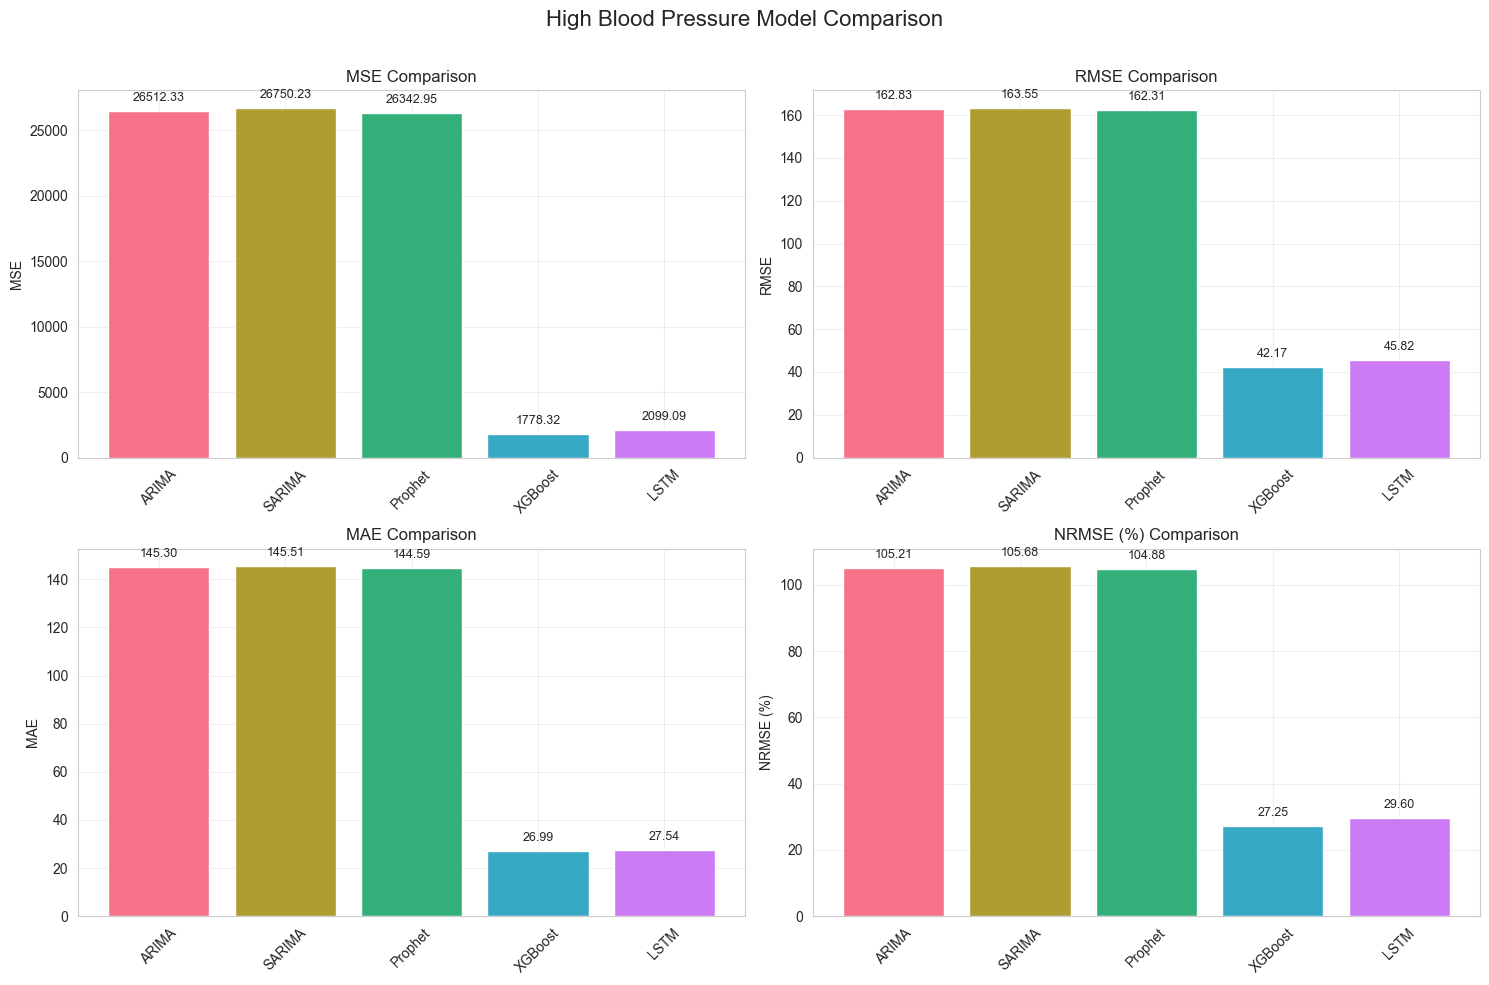

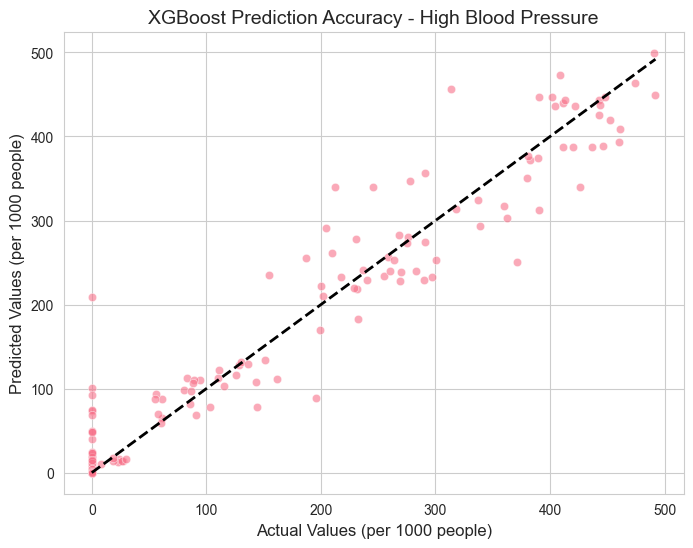


=== High Blood Pressure Model Metrics (per 1000 people) ===
                  MSE        RMSE         MAE   NRMSE (%)
ARIMA    26512.333345  162.826083  145.304539  105.213845
SARIMA   26750.232359  163.554983  145.510720  105.684840
Prophet  26342.952938  162.305123  144.594919  104.877215
XGBoost   1778.321974   42.170155   26.994034   27.249222
LSTM      2099.087607   45.815801   27.542518   29.604941

=== High Blood Pressure XGBoost Feature Importance ===


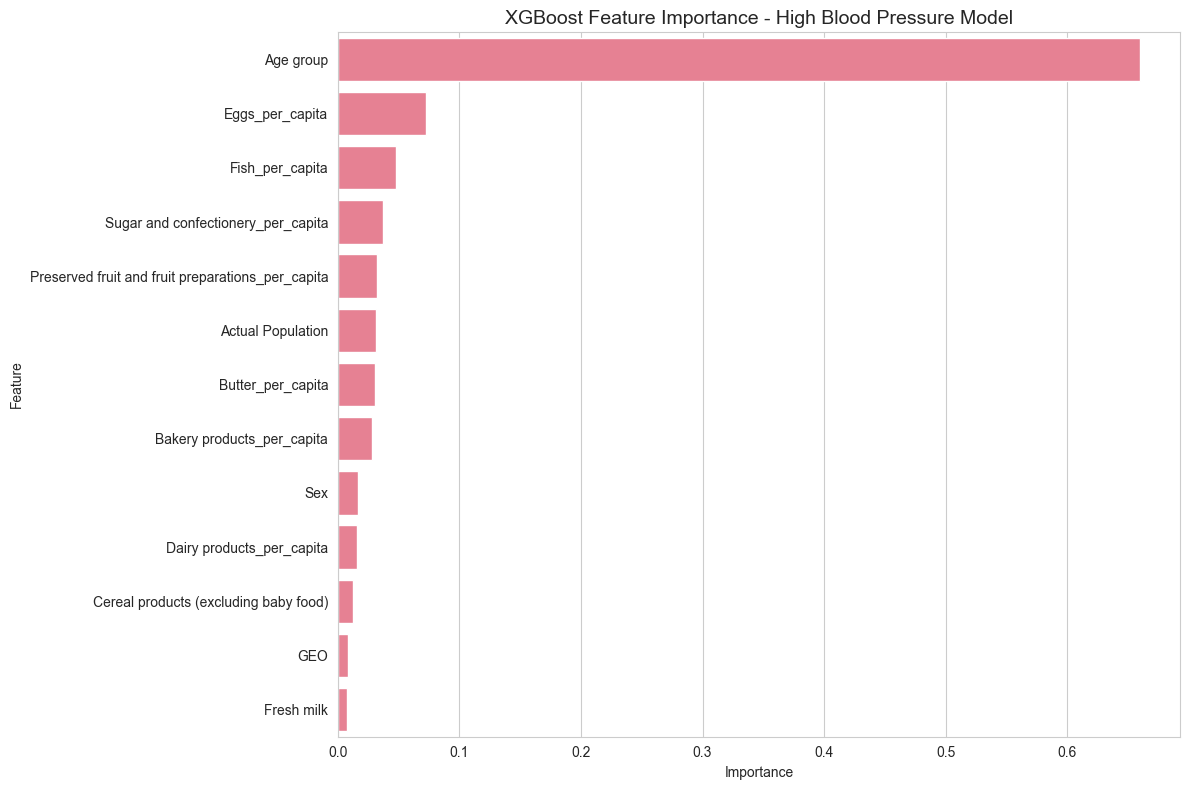


=== Model Comparison Summary ===
Best model for Diabetes: LSTM
Best model for High Blood Pressure: XGBoost


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
sns.set_palette("husl")

# Load the data
data = pd.read_excel(r"C:\Users\ASUS\Downloads\V5_Capstone_Final_Dataset.xlsx")

# Convert REF_DATE to datetime
data['REF_DATE'] = pd.to_datetime(data['REF_DATE'])
data = data.sort_values('REF_DATE')

# Encode categorical variables
label_encoders = {}
categorical_features = ['GEO', 'Age group', 'Sex']

for col in categorical_features:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  # Store encoders for future reference

# Define feature sets based on feature selection results
# Common features for both models
common_features = ['GEO', 'Age group', 'Sex', 'Actual Population']

# Features specifically for Diabetes model (based on your feature selection)
diabetes_features = [
    # Features that appear in all three methods
    'Sugar and confectionery', 'Eggs', 'Bakery products', 'Butter',
    # Features that appear in two methods
    'Dairy products', 'Cheese', 'Fresh vegetables', 
    'Preserved fruit and fruit preparations', 'Edible fats and oils',
    'Fish', 'Non-alcoholic beverages', 
    'Preserved vegetables and vegetable preparations'
]

# Features specifically for High Blood Pressure model (based on your feature selection)
hbp_features = [
    # Features that appear in all three methods
    'Sugar and confectionery', 'Eggs', 'Bakery products', 'Butter',
    # Features that appear in two methods
    'Dairy products', 'Preserved fruit and fruit preparations', 
    'Fish', 'Fresh milk', 'Cereal products (excluding baby food)'
]

# Create feature sets for each target
X_diabetes = data[common_features + diabetes_features]
X_hbp = data[common_features + hbp_features]
y_diabetes = data['Diabetes']
y_hbp = data['High Blood Pressure']

# Feature normalization - normalize values to account for population differences
# This can help make the error metrics more realistic
scaling_features = [col for col in X_diabetes.columns if col not in ['GEO', 'Age group', 'Sex']]
for col in scaling_features:
    if col != 'Actual Population':  # Don't normalize population itself
        data[col + '_per_capita'] = data[col] / data['Actual Population'] * 1000  # per 1000 people

# Apply the same normalization to target variables
data['Diabetes_per_capita'] = data['Diabetes'] / data['Actual Population'] * 1000  # per 1000 people
data['HBP_per_capita'] = data['High Blood Pressure'] / data['Actual Population'] * 1000  # per 1000 people

# Create normalized feature sets
diabetes_features_norm = [f + '_per_capita' if f in scaling_features and f != 'Actual Population' else f for f in diabetes_features]
hbp_features_norm = [f + '_per_capita' if f in scaling_features and f != 'Actual Population' else f for f in hbp_features]

X_diabetes_norm = data[common_features + diabetes_features_norm]
X_hbp_norm = data[common_features + hbp_features_norm]
y_diabetes_norm = data['Diabetes_per_capita']
y_hbp_norm = data['HBP_per_capita']

# Split the data - using normalized datasets
X_diabetes_train, X_diabetes_test, y_diabetes_train, y_diabetes_test, dates_diabetes_train, dates_diabetes_test = train_test_split(
    X_diabetes_norm, y_diabetes_norm, data['REF_DATE'], test_size=0.2, random_state=42)

X_hbp_train, X_hbp_test, y_hbp_train, y_hbp_test, dates_hbp_train, dates_hbp_test = train_test_split(
    X_hbp_norm, y_hbp_norm, data['REF_DATE'], test_size=0.2, random_state=42)

# Standardize the features
diabetes_scaler = StandardScaler()
X_diabetes_train_scaled = diabetes_scaler.fit_transform(X_diabetes_train)
X_diabetes_test_scaled = diabetes_scaler.transform(X_diabetes_test)

hbp_scaler = StandardScaler()
X_hbp_train_scaled = hbp_scaler.fit_transform(X_hbp_train)
X_hbp_test_scaled = hbp_scaler.transform(X_hbp_test)

# Model evaluation function
def evaluate_model(y_true, y_pred, model_name, results_dict):
    # Clip negative predictions to 0 (can't have negative disease rates)
    y_pred = np.clip(y_pred, 0, None)
    
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    
    # Calculate normalized errors - useful for comparing models
    y_mean = np.mean(y_true)
    normalized_rmse = rmse / y_mean * 100  # as percentage of mean
    
    results_dict[model_name] = {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'NRMSE (%)': normalized_rmse,
        'Predictions': y_pred.copy(),
        'Actual': y_true.copy()
    }
    return y_pred

# Define improved model training functions
def fit_arima(y_train, y_test, results_dict):
    # Try more suitable parameters
    model = ARIMA(y_train, order=(3, 1, 2)).fit()
    forecast = model.forecast(steps=len(y_test))
    return evaluate_model(y_test, forecast, "ARIMA", results_dict)

def fit_sarima(y_train, y_test, results_dict):
    # Improved parameters
    model = SARIMAX(y_train, order=(2, 1, 2), seasonal_order=(1, 0, 1, 12)).fit(disp=False)
    forecast = model.forecast(steps=len(y_test))
    return evaluate_model(y_test, forecast, "SARIMA", results_dict)

def fit_prophet(y_train, y_test, dates_train, dates_test, results_dict):
    df = pd.DataFrame({'ds': dates_train, 'y': y_train})
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
    model.fit(df)
    forecast = model.predict(pd.DataFrame({'ds': dates_test}))
    return evaluate_model(y_test, forecast['yhat'].values, "Prophet", results_dict)

def fit_xgboost(X_train, X_test, y_train, y_test, results_dict):
    # Improved XGBoost parameters for better performance
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    return evaluate_model(y_test, predictions, "XGBoost", results_dict)

def fit_lstm(X_train, X_test, y_train, y_test, results_dict):
    # Reshape data for LSTM
    X_train_reshaped = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
    X_test_reshaped = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))
    
    # Build improved LSTM model
    model = Sequential([
        LSTM(64, activation='relu', input_shape=(1, X_train.shape[1]), return_sequences=True),
        Dropout(0.2),  # Prevent overfitting
        LSTM(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    model.fit(
        X_train_reshaped, y_train, 
        epochs=100,  # More epochs for better learning
        batch_size=16,  # Smaller batch size
        verbose=0,
        validation_split=0.1  # Use some training data for validation
    )
    
    predictions = model.predict(X_test_reshaped).flatten()
    return evaluate_model(y_test, predictions, "LSTM", results_dict)

# Visualization functions
def plot_time_series_comparison(dates_test, y_true, predictions_dict, title):
    df = pd.DataFrame({
        'Date': dates_test,
        'Actual': y_true
    })
    for model_name, pred in predictions_dict.items():
        df[model_name] = pred
    
    df = df.sort_values('Date').reset_index(drop=True)
    
    plt.figure(figsize=(15, 10))
    plt.suptitle(title, fontsize=16, y=1.02)
    
    models = list(predictions_dict.keys())
    for i, model in enumerate(models, 1):
        plt.subplot(3, 2, i)
        sns.lineplot(data=df, x='Date', y='Actual', label='Actual')
        sns.lineplot(data=df, x='Date', y=model, label=model)
        plt.title(f'{model} vs Actual')
        plt.xlabel('Date')
        plt.ylabel('Cases per 1000 people')
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metrics_comparison(results_dict, title):
    metrics = ['MSE', 'RMSE', 'MAE', 'NRMSE (%)']
    model_names = list(results_dict.keys())
    
    # Create subplots for different metrics
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        values = [results_dict[name][metric] for name in model_names]
        axes[i].bar(model_names, values, color=sns.color_palette("husl", len(model_names)))
        axes[i].set_title(f'{metric} Comparison', fontsize=12)
        axes[i].set_ylabel(metric, fontsize=10)
        axes[i].set_xticklabels(model_names, rotation=45)
        axes[i].grid(True, alpha=0.3)
        
        # Add values on top of bars
        for j, v in enumerate(values):
            axes[i].text(j, v + (max(values) * 0.02), f'{v:.2f}', 
                     ha='center', va='bottom', fontsize=9)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

def plot_predicted_vs_actual(y_true, y_pred, model_name, title):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=2)
    plt.title(f'{model_name} Prediction Accuracy - {title}', fontsize=14)
    plt.xlabel('Actual Values (per 1000 people)', fontsize=12)
    plt.ylabel('Predicted Values (per 1000 people)', fontsize=12)
    plt.grid(True)
    plt.show()

def determine_best_model(results_dict):
    # Choose the model with the lowest RMSE
    return min(results_dict, key=lambda k: results_dict[k]['RMSE'])

# Run improved comparisons for Diabetes (per capita)
print("\nDiabetes Forecasting (per 1000 people):")
diabetes_results = {}

# Time series models
arima_diabetes_pred = fit_arima(y_diabetes_train, y_diabetes_test, diabetes_results)
sarima_diabetes_pred = fit_sarima(y_diabetes_train, y_diabetes_test, diabetes_results)
prophet_diabetes_pred = fit_prophet(y_diabetes_train, y_diabetes_test, dates_diabetes_train, dates_diabetes_test, diabetes_results)

# Machine learning models
xgboost_diabetes_pred = fit_xgboost(X_diabetes_train_scaled, X_diabetes_test_scaled, y_diabetes_train, y_diabetes_test, diabetes_results)
lstm_diabetes_pred = fit_lstm(X_diabetes_train_scaled, X_diabetes_test_scaled, y_diabetes_train, y_diabetes_test, diabetes_results)

# Create predictions dictionary for diabetes
diabetes_predictions = {
    'ARIMA': arima_diabetes_pred,
    'SARIMA': sarima_diabetes_pred,
    'Prophet': prophet_diabetes_pred,
    'XGBoost': xgboost_diabetes_pred,
    'LSTM': lstm_diabetes_pred
}

# Plot time series comparison for diabetes
plot_time_series_comparison(dates_diabetes_test, y_diabetes_test, diabetes_predictions, 'Diabetes Forecasting Comparison (per 1000 people)')

# Plot metrics comparison for diabetes
plot_metrics_comparison(diabetes_results, 'Diabetes Model Comparison')

# Plot predicted vs actual for best model
best_diabetes_model = determine_best_model(diabetes_results)
best_diabetes_predictions = diabetes_predictions[best_diabetes_model]
plot_predicted_vs_actual(y_diabetes_test, best_diabetes_predictions, best_diabetes_model, 'Diabetes')

# Print model metrics for Diabetes
print("\n=== Diabetes Model Metrics (per 1000 people) ===")
diabetes_metrics = pd.DataFrame({model: {metric: results_dict[metric] for metric in ['MSE', 'RMSE', 'MAE', 'NRMSE (%)']}
                                for model, results_dict in diabetes_results.items()}).T
print(diabetes_metrics)

# Run improved comparisons for High Blood Pressure (per capita)
print("\nHigh Blood Pressure Forecasting (per 1000 people):")
hbp_results = {}

# Time series models
arima_hbp_pred = fit_arima(y_hbp_train, y_hbp_test, hbp_results)
sarima_hbp_pred = fit_sarima(y_hbp_train, y_hbp_test, hbp_results)
prophet_hbp_pred = fit_prophet(y_hbp_train, y_hbp_test, dates_hbp_train, dates_hbp_test, hbp_results)

# Machine learning models
xgboost_hbp_pred = fit_xgboost(X_hbp_train_scaled, X_hbp_test_scaled, y_hbp_train, y_hbp_test, hbp_results)
lstm_hbp_pred = fit_lstm(X_hbp_train_scaled, X_hbp_test_scaled, y_hbp_train, y_hbp_test, hbp_results)

# Create predictions dictionary for high blood pressure
hbp_predictions = {
    'ARIMA': arima_hbp_pred,
    'SARIMA': sarima_hbp_pred,
    'Prophet': prophet_hbp_pred,
    'XGBoost': xgboost_hbp_pred,
    'LSTM': lstm_hbp_pred
}

# Plot time series comparison for high blood pressure
plot_time_series_comparison(dates_hbp_test, y_hbp_test, hbp_predictions, 'High Blood Pressure Forecasting Comparison (per 1000 people)')

# Plot metrics comparison for high blood pressure
plot_metrics_comparison(hbp_results, 'High Blood Pressure Model Comparison')

# Plot predicted vs actual for best model
best_hbp_model = determine_best_model(hbp_results)
best_hbp_predictions = hbp_predictions[best_hbp_model]
plot_predicted_vs_actual(y_hbp_test, best_hbp_predictions, best_hbp_model, 'High Blood Pressure')

# Print model metrics for High Blood Pressure
print("\n=== High Blood Pressure Model Metrics (per 1000 people) ===")
hbp_metrics = pd.DataFrame({model: {metric: results_dict[metric] for metric in ['MSE', 'RMSE', 'MAE', 'NRMSE (%)']}
                          for model, results_dict in hbp_results.items()}).T
print(hbp_metrics)

# Feature importance analysis for the best model (assuming XGBoost)
if best_diabetes_model == 'XGBoost':
    print("\n=== Diabetes XGBoost Feature Importance ===")
    # Re-train the model on the full dataset
    diabetes_xgb = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        random_state=42
    )
    diabetes_xgb.fit(X_diabetes_train_scaled, y_diabetes_train)
    
    # Get feature importance
    importance = diabetes_xgb.feature_importances_
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    feat_importance = pd.DataFrame({
        'Feature': X_diabetes_train.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    sns.barplot(x='Importance', y='Feature', data=feat_importance[:15])  # Top 15 features
    plt.title('XGBoost Feature Importance - Diabetes Model', fontsize=14)
    plt.tight_layout()
    plt.show()

if best_hbp_model == 'XGBoost':
    print("\n=== High Blood Pressure XGBoost Feature Importance ===")
    # Re-train the model on the full dataset
    hbp_xgb = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=2,
        subsample=0.8,
        colsample_bytree=0.8,
        gamma=0.1,
        random_state=42
    )
    hbp_xgb.fit(X_hbp_train_scaled, y_hbp_train)
    
    # Get feature importance
    importance = hbp_xgb.feature_importances_
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    feat_importance = pd.DataFrame({
        'Feature': X_hbp_train.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    sns.barplot(x='Importance', y='Feature', data=feat_importance[:15])  # Top 15 features
    plt.title('XGBoost Feature Importance - High Blood Pressure Model', fontsize=14)
    plt.tight_layout()
    plt.show()

# Print summary and conclusions
print("\n=== Model Comparison Summary ===")
print(f"Best model for Diabetes: {best_diabetes_model}")
print(f"Best model for High Blood Pressure: {best_hbp_model}")